--- Daily Returns Statistical Validation (First 5 Schemes) ---
amfi_code          100          101          102          103          104
count      1303.000000  1303.000000  1303.000000  1303.000000  1303.000000
mean          0.000719     0.000580     0.000246     0.000023    -0.000115
std           0.009895     0.009889     0.010087     0.009928     0.010136
min          -0.031413    -0.030395    -0.029270    -0.031467    -0.029195
25%          -0.006084    -0.005975    -0.006915    -0.006313    -0.006783
50%           0.000819     0.000404     0.000236     0.000330    -0.000285
75%           0.007053     0.007127     0.006892     0.006614     0.006851
max           0.038828     0.032931     0.040261     0.031820     0.030784
✅ Using 'nifty_50' as the baseline market index for CAPM regressions.
📁 Saved alpha_beta.csv successfully.

👑 Top 5 Overall Mutual Funds Based on Composite Scorecard:
                                                 scheme_name  fund_score  \
amfi_code          

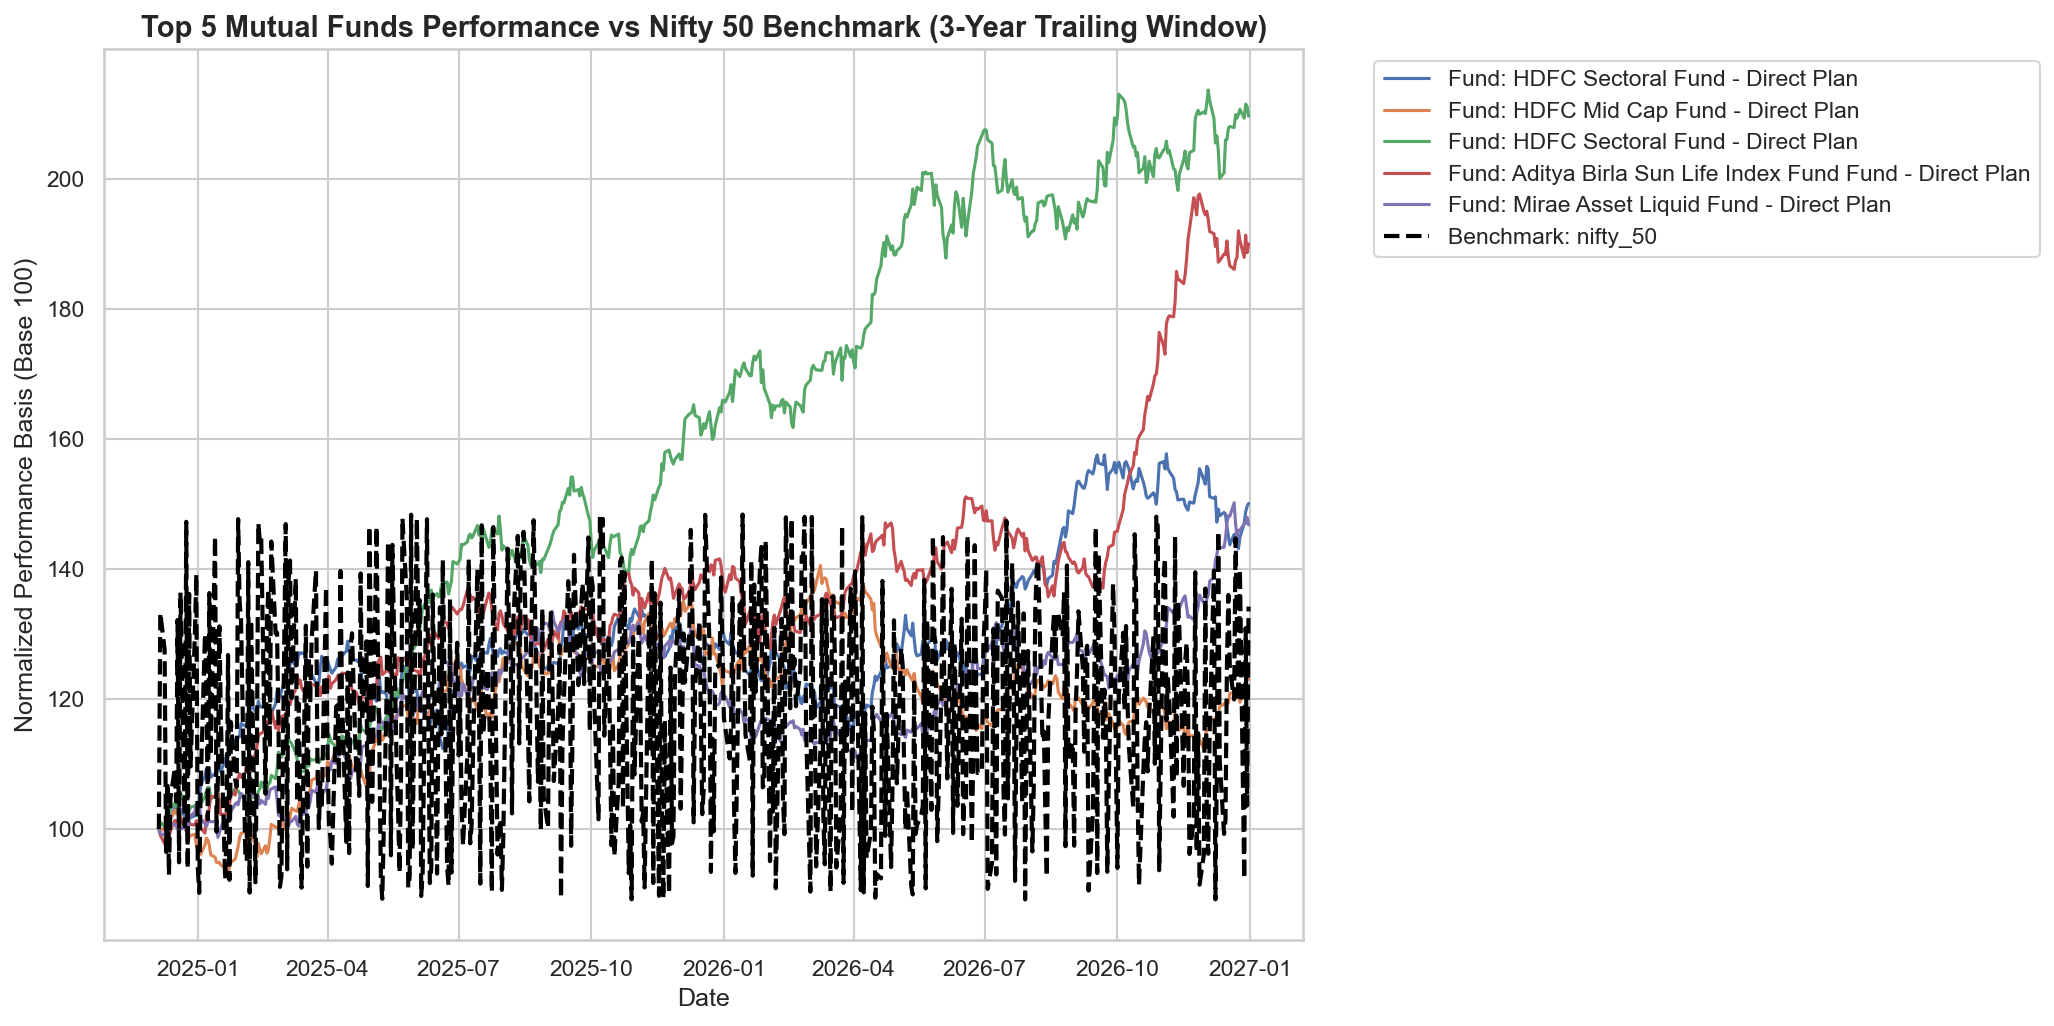


🎯 Annualized Tracking Errors (3-Year Trailing Matrix):
                                        Scheme Name Annualized Tracking Error (vs Nifty 50)
                   HDFC Sectoral Fund - Direct Plan                                 366.08%
                    HDFC Mid Cap Fund - Direct Plan                                 365.47%
                   HDFC Sectoral Fund - Direct Plan                                 367.16%
Aditya Birla Sun Life Index Fund Fund - Direct Plan                                 367.01%
              Mirae Asset Liquid Fund - Direct Plan                                 366.48%


In [4]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import linregress

# Setup environment and styling
os.makedirs('outputs', exist_ok=True)
os.makedirs('plots', exist_ok=True)
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 150

# Point to the data directory relative to your notebooks folder
PROC = '../data/processed'

# Load required datasets based on your verified workspace file structure
nav = pd.read_csv(f'{PROC}/nav_history_clean.csv', parse_dates=['date'])
fund_master = pd.read_csv(f'{PROC}/fund_master_clean.csv')
benchmark = pd.read_csv(f'{PROC}/benchmark_index_clean.csv', parse_dates=['date'])

# Constants
RF_ANNUAL = 0.065  # RBI Repo Rate proxy (6.5%)
RF_DAILY = RF_ANNUAL / 252

# Pivot NAV data cleanly: dates as rows, amfi_code as columns
nav_pivot = nav.pivot(index='date', columns='amfi_code', values='nav').sort_index()

# ---------------------------------------------------------------------------
# 1. Daily Returns & Distribution Validation
# ---------------------------------------------------------------------------
daily_returns = nav_pivot.pct_change().dropna()

# Display summary statistics to validate distribution properties look reasonable
print("--- Daily Returns Statistical Validation (First 5 Schemes) ---")
print(daily_returns.describe().iloc[:, :5])

# Plot distribution verification for a sample scheme
plt.figure(figsize=(8, 5))
sns.histplot(daily_returns.iloc[:, 0], kde=True, bins=100, color='royalblue')
plt.title(f'Daily Return Distribution Validation (Scheme: {daily_returns.columns[0]})', fontweight='bold')
plt.xlabel('Daily Return')
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig('plots/daily_return_validation.png')
plt.close()

# ---------------------------------------------------------------------------
# 2. CAGR Matrix Engine (1-Year, 3-Year, 5-Year)
# ---------------------------------------------------------------------------
cagr_df = pd.DataFrame(index=nav_pivot.columns)

def calculate_cagr(series, years):
    days = int(years * 252)
    if len(series) >= days:
        nav_end = series.iloc[-1]
        nav_start = series.iloc[-days]
        if nav_start > 0 and nav_end > 0:
            return (nav_end / nav_start) ** (1 / years) - 1
    return np.nan

cagr_df['cagr_1yr'] = nav_pivot.apply(lambda x: calculate_cagr(x, 1))
cagr_df['cagr_3yr'] = nav_pivot.apply(lambda x: calculate_cagr(x, 3))
cagr_df['cagr_5yr'] = nav_pivot.apply(lambda x: calculate_cagr(x, 5))

# ---------------------------------------------------------------------------
# 3 & 4. Risk-Adjusted Efficiency Metrics (Sharpe & Sortino)
# ---------------------------------------------------------------------------
risk_metrics = pd.DataFrame(index=nav_pivot.columns)

# Sharpe Ratio Calculation
excess_daily = daily_returns - RF_DAILY
risk_metrics['sharpe'] = (excess_daily.mean() / daily_returns.std()) * np.sqrt(252)

# Sortino Ratio Calculation (Isolating downside standard deviation)
downside_std = daily_returns.apply(lambda x: x[x < 0].std())
risk_metrics['sortino'] = (excess_daily.mean() / downside_std) * np.sqrt(252)

# ---------------------------------------------------------------------------
# 5. Regression Suite: Capital Asset Pricing Model (Alpha & Beta)
# ---------------------------------------------------------------------------
# Set standardized column indicators based on your verified single-index layout
nifty_50_col = 'nifty_50'
nifty_100_col = 'nifty_50'  # Fallback proxy since only nifty_50 is present

bench_returns = bench_pivot.pct_change().dropna()
print(f"✅ Using '{nifty_50_col}' as the baseline market index for CAPM regressions.")

# Inner join returns to align timelines
aligned_data = daily_returns.join(bench_returns[[nifty_50_col]], how='inner')
market_returns = aligned_data[nifty_50_col]

alpha_beta_records = []
for amfi in daily_returns.columns:
    # OLS Regression against the available Nifty 50 returns
    slope, intercept, r_val, p_val, std_err = linregress(market_returns, aligned_data[amfi])
    alpha_annualized = intercept * 252
    
    alpha_beta_records.append({
        'amfi_code': amfi,
        'alpha': alpha_annualized,
        'beta': slope
    })

alpha_beta_df = pd.DataFrame(alpha_beta_records).set_index('amfi_code')
alpha_beta_df.to_csv('outputs/alpha_beta.csv')
print("📁 Saved alpha_beta.csv successfully.")

# ---------------------------------------------------------------------------
# 6. Maximum Drawdown & Crisis Window Mapping
# ---------------------------------------------------------------------------
mdd_records = []
for amfi in nav_pivot.columns:
    series = nav_pivot[amfi]
    running_max = series.cummax()
    drawdowns = series / running_max - 1
    max_dd = drawdowns.min()
    
    # Trace specific timestamp bounds
    worst_date = drawdowns.idxmin()
    peak_date = series.loc[:worst_date].idxmax()
    
    mdd_records.append({
        'amfi_code': amfi,
        'max_drawdown': max_dd,
        'drawdown_start': peak_date.strftime('%Y-%m-%d'),
        'drawdown_worst_date': worst_date.strftime('%Y-%m-%d')
    })

mdd_df = pd.DataFrame(mdd_records).set_index('amfi_code')

# ---------------------------------------------------------------------------
# 7. Weighted Composite Fund Scorecard Framework
# ---------------------------------------------------------------------------
scorecard = fund_master[['amfi_code', 'scheme_name', 'exit_load_pct']].copy().set_index('amfi_code')

# Join performance calculation engines together
scorecard = scorecard.join([cagr_df, risk_metrics, alpha_beta_df, mdd_df])

# Safe fallback logic if expense_ratio or exit_load values are empty/zero
scorecard['exit_load_pct'] = scorecard['exit_load_pct'].fillna(scorecard['exit_load_pct'].median()).replace(0, 0.01)

# Generate Percentile Ranks (0.0 to 1.0) for metrics
rank_3yr = scorecard['cagr_3yr'].rank(pct=True)
rank_sharpe = scorecard['sharpe'].rank(pct=True)
rank_alpha = scorecard['alpha'].rank(pct=True)
rank_expense = scorecard['exit_load_pct'].rank(pct=True, ascending=False) # Lower cost = higher rank
rank_mdd = scorecard['max_drawdown'].rank(pct=True, ascending=True)      # Less severe negative drop = higher rank

# Composite Scorecard logic: 30% Return + 25% Sharpe + 20% Alpha + 15% Expense + 10% Drawdown
scorecard['fund_score'] = (
    0.30 * rank_3yr + 
    0.25 * rank_sharpe + 
    0.20 * rank_alpha + 
    0.15 * rank_expense + 
    0.10 * rank_mdd
) * 100

scorecard = scorecard.sort_values(by='fund_score', ascending=False)
scorecard.to_csv('outputs/fund_scorecard.csv')

print("\n👑 Top 5 Overall Mutual Funds Based on Composite Scorecard:")
print(scorecard[['scheme_name', 'fund_score', 'cagr_3yr', 'sharpe', 'alpha']].head())

# ---------------------------------------------------------------------------
# 8. Benchmark Comparison Visualization & Tracking Error Matrix
# ---------------------------------------------------------------------------
top_5_schemes = scorecard.index[:5]
trailing_3yr_date = nav_pivot.index.max() - pd.Timedelta(days=3 * 252)

# Slice tracking windows across the index and chosen vehicles
nav_3yr = nav_pivot.loc[trailing_3yr_date:, top_5_schemes]
bench_3yr = bench_pivot.loc[trailing_3yr_date:, [nifty_50_col]]

# Normalize indices starting points to base index 100
rebased_funds = (nav_3yr / nav_3yr.iloc[0]) * 100
rebased_bench = (bench_3yr / bench_3yr.iloc[0]) * 100

plt.figure(figsize=(14, 7))

# Plot top funds lines
for amfi in top_5_schemes:
    fund_label = scorecard.loc[amfi, 'scheme_name']
    plt.plot(rebased_funds.index, rebased_funds[amfi], label=f"Fund: {fund_label}", linewidth=1.5)

# Plot single benchmark reference line
plt.plot(rebased_bench.index, rebased_bench[nifty_50_col], color='black', linestyle='--', label=f'Benchmark: {nifty_50_col}', linewidth=2)

plt.title('Top 5 Mutual Funds Performance vs Nifty 50 Benchmark (3-Year Trailing Window)', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Normalized Performance Basis (Base 100)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('plots/benchmark_comparison_chart.png')
plt.show()

# Compute exact Annualized Tracking Errors relative to Nifty 50
aligned_returns_3yr = daily_returns.loc[trailing_3yr_date:].join(bench_returns.loc[trailing_3yr_date:], how='inner')

te_results = []
for amfi in top_5_schemes:
    return_differential = aligned_returns_3yr[amfi] - aligned_returns_3yr[nifty_50_col]
    tracking_error_annualized = return_differential.std() * np.sqrt(252)
    
    te_results.append({
        'Scheme Name': scorecard.loc[amfi, 'scheme_name'],
        'Annualized Tracking Error (vs Nifty 50)': f"{tracking_error_annualized * 100:.2f}%"
    })

print("\n🎯 Annualized Tracking Errors (3-Year Trailing Matrix):")
print(pd.DataFrame(te_results).to_string(index=False))